# Preparation of Survey items to validate GBN classification
Felix Zaussinger | 21.07.2022

**Core Analysis Goal(s)**
1. Code for stratified random draw of green, brown and neutral occupations from our consolidated short lists
2. Export to text files along the lines of Malte's approach
3. Implement in Qualtrics

**Key Insight(s)**
1.
2.
3.

In [114]:
import os
import sys
import logging
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from src import utils
#import mapping_career_causeways

# OPTIONAL: Load the "autoreload" extension so that code can change
%load_ext autoreload

# OPTIONAL: always reload modules so that as you change code in src, it gets loaded
%autoreload 2

# Settings
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

sns.set_context("notebook")
#sns.set(rc={'figure.figsize': (16, 9.)})
sns.set_style("ticks")

pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 120)

logging.basicConfig(level=logging.INFO, stream=sys.stdout)

# load paths
useful_paths = utils.UsefulPaths()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


#### Input data

In [3]:
df_sl = pd.read_csv(
    os.path.join(useful_paths.data_processed, "esco", "esco_level_gbn_classification_short_lists.csv"),
    index_col=0
)

df_sl_tobi = pd.read_csv(
    os.path.join(useful_paths.data_processed, "esco", "esco_level_gbn_classification_short_lists_tobi.csv"),
    index_col=0
)

#### Comparison between ESCO-based and manual classification
- [quantification via confusion matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html#sklearn.metrics.confusion_matrix)
- very little overlap
- not very surprising though as the reference classification is based on assigning the class with the highest skill share, so neutral occupations will dominate


In [4]:
from sklearn.metrics import confusion_matrix, multilabel_confusion_matrix

labels = ["green", "brown", "neutral"]
cm = confusion_matrix(
    y_true=df_sl.gbn_classification_short_list,
    y_pred=df_sl.gbn_classification_esco,
    labels=labels,
    #normalize="true"
)

cm_sl = pd.DataFrame(cm, columns=labels, index=labels)
cm_sl

,green,brown,neutral
green,25,0,66
brown,0,2,205
neutral,4,0,2706


In [5]:
labels = ["green", "brown", "neutral"]
cm = confusion_matrix(
    y_true=df_sl_tobi.gbn_classification_short_list,
    y_pred=df_sl_tobi.gbn_classification_esco,
    labels=labels,
    #normalize="true"
)

cm_sl_tobi = pd.DataFrame(cm, columns=labels, index=labels)
cm_sl_tobi

,green,brown,neutral
green,25,0,66
brown,0,0,63
neutral,4,2,2848


In [104]:
df_sl.groupby("gbn_classification_short_list").count()

,conceptUri,preferredLabel,description,gbn_classification_esco,gbn_classification_esco_ess
gbn_classification_short_list,,,,,
brown,207,207,207,207,207
green,91,91,91,91,91
neutral,2710,2710,2710,2710,2709


#### Stratified random draw

- use `.groupby` combined with `.sample` to draw N samples for each category
- use `.sample(frac=1)` to shuffle the sample
- [link](https://stackoverflow.com/questions/44114463/stratified-sampling-in-pandas)

In [6]:
# select list version
df = df_sl

# sample size per category
n_sample = 10
n_categories = 3

# random draw of size n_sample out of each category (n_sample * 3 categories)
strat_sample = df.groupby("gbn_classification_short_list", group_keys=False).apply(lambda x: x.sample(min(len(x), n_sample)))

# shuffle the sample
strat_sample_shuffled = strat_sample.sample(frac=1)

strat_sample_shuffled

,conceptUri,preferredLabel,description,gbn_classification_esco,gbn_classification_esco_ess,gbn_classification_short_list
732,http://data.europa.eu/esco/occupation/c8e6cdcc...,geochemist,Geochemists study the characteristics and chem...,neutral,neutral,neutral
1094,http://data.europa.eu/esco/occupation/49f1e9aa...,drawing kiln operator,Drawing kiln operators are responsible for con...,neutral,neutral,brown
1540,http://data.europa.eu/esco/occupation/c0ec3a06...,decontamination worker,Decontamination workers remove and dispose of ...,neutral,green,green
1010,http://data.europa.eu/esco/occupation/2a7d4b37...,pipeline pump operator,Pipeline pump operators tend pump equipment an...,neutral,neutral,brown
770,http://data.europa.eu/esco/occupation/fab474ea...,natural resources consultant,Natural resources consultant provide advice on...,green,green,green
952,http://data.europa.eu/esco/occupation/53d55c80...,leather goods stitching machine operator,Leather goods stitching machine operators join...,neutral,neutral,neutral
765,http://data.europa.eu/esco/occupation/80d880ec...,nature conservation officer,Nature conservation officers manage and improv...,green,green,green
767,http://data.europa.eu/esco/occupation/bff716c9...,aquaculture environmental analyst,"Aquaculture environmental analysts assess, pla...",green,green,green
1801,http://data.europa.eu/esco/occupation/23993e79...,mine shift manager,"Mine shift managers supervise staff, manage pl...",neutral,neutral,brown
1046,http://data.europa.eu/esco/occupation/bb131b09...,pulp technician,Pulp technicians perform technical tasks in th...,neutral,neutral,brown


#### test_set_v1
- 30 occupations per participant
- no condition that each occupation needs to be seen by two participants

In [124]:
# directory and files
target_dir = r"T:\Documents\Projects\04_jrc_green-skills-regional\02_research\user study"
target_folder = "test_set_v1"
target_file = "test_set_shuffled_{}.txt"

# select list version
df = df_sl

# sample size per category
n_sample = 10
n_categories = 3
n_surveys = 20
newline = "\n"

# create N surveys
all_samples = []
for survey_id in range(1, n_surveys + 1):

    # random draw of size n_sample out of each category (n_sample * 3 categories), then shuffle the sample
    strat_sample = df.groupby("gbn_classification_short_list", group_keys=False).apply(lambda x: x.sample(min(len(x), n_sample)))
    strat_sample_shuffled = strat_sample.sample(frac=1)
    all_samples.append(strat_sample_shuffled)

    # create new survey file
    f = open(os.path.join(target_dir, target_folder, target_file.format(survey_id)), "w+", encoding="utf-8")

    # iterate over occupations in drawn sample
    item_count = 1
    for i, row in strat_sample_shuffled.iterrows():
        occ_label = row["preferredLabel"]
        occ_desc = row["description"]

        # build question/answer structure
        f.write("{}. {}\n".format(item_count, occ_desc))
        f.write(newline)
        f.write("Green\nBrown\nNeutral\nUnsure\n")
        f.write(newline)

        # make sure no block is added after the last question
        if item_count < n_sample * n_categories:
            f.write("[[Block]]")
            f.write(newline)

        # update count
        item_count += 1

    f.close()

gbn_classification_short_list
brown      136
green       83
neutral    194
Name: conceptUri, dtype: int64
                               duplicate
gbn_classification_short_list           
brown                                 64
green                                117
neutral                                6


<AxesSubplot:>

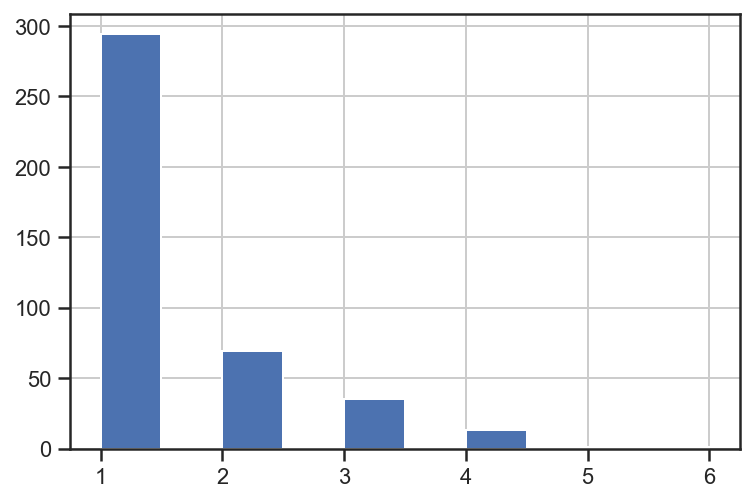

In [136]:
df_all_samples = pd.concat(all_samples)

# unique occupations per category
df_all_samples.groupby("gbn_classification_short_list").count()
print(df_all_samples.drop_duplicates().groupby("gbn_classification_short_list").count
      ().iloc[:, 0])

# duplicates per category
df_all_samples["duplicate"] = df_all_samples.duplicated()
print(df_all_samples.groupby("gbn_classification_short_list").sum())

# all occupations in the sample at least twice?
df_all_samples.groupby("preferredLabel").count().iloc[:, 0].hist()

#### test_set_v2
- 30 occupations per participant
- condition that each occupation needs to be seen by two participants
- surveys with uneven IDs are unique draws, surveys with the following even ID
contain the same sample, but a shuffled set

In [137]:
# directory and files
target_dir = r"T:\Documents\Projects\04_jrc_green-skills-regional\02_research\user study"
target_folder = "test_set_v3"
target_file = "test_set_shuffled_{}.txt"

if not os.path.exists(os.path.join(target_dir, target_folder)):
    os.makedirs(os.path.join(target_dir, target_folder))

# select list version
df = df_sl

# sample size per category
n_sample = 10
n_categories = 3
n_surveys = 20
newline = "\n"
seed = 42

# create N surveys
all_samples = []
for survey_id in range(1, n_surveys + 1):

    # create unique draw for uneven survey id's
    if (survey_id % 2) != 0:
        # random draw of size n_sample out of each category (n_sample * 3 categories)
        strat_sample = df.groupby(
            "gbn_classification_short_list", group_keys=False
        ).apply(lambda x: x.sample(min(len(x), n_sample)))

    # shuffle the sample: for even survey id's, the sample of the previous (uneven) id is shuffled
    strat_sample_shuffled = strat_sample.sample(frac=1)
    all_samples.append(strat_sample_shuffled)

    # create new survey file
    f = open(os.path.join(target_dir, target_folder, target_file.format(survey_id)), "w+", encoding="utf-8")

    # iterate over occupations in drawn sample
    item_count = 1
    for i, row in strat_sample_shuffled.iterrows():
        occ_label = row["preferredLabel"]
        occ_desc = row["description"]

        # build question/answer structure
        f.write("{}. {}\n".format(item_count, occ_desc))
        f.write(newline)
        f.write("Green\nBrown\nNeutral\nUnsure\n")
        f.write(newline)

        # make sure no block is added after the last question
        if item_count < n_sample * n_categories:
            f.write("[[Block]]")
            f.write(newline)

        # update count
        item_count += 1

    f.close()

#### Evaluation of sample
- note that since some categories are smaller (G < B < N), more duplicates are in the
 combined sample overall
- ~ 240 / 600 occupations are unique
- start by sending out links of all surveys with an uneven ID to get 100% coverage
with 10 participants (1, 3, ..., 19)
- then start sending out the even links (2, 4, ..., 20)

gbn_classification_short_list
brown       79
green       62
neutral    100
Name: conceptUri, dtype: int64
                               duplicate
gbn_classification_short_list           
brown                                121
green                                138
neutral                              100


,conceptUri,description,gbn_classification_esco,gbn_classification_esco_ess,gbn_classification_short_list,duplicate
preferredLabel,,,,,,
ICT auditor manager,2,2,2,2,2,2
ICT environmental manager,4,4,4,4,4,4
V-belt builder,2,2,2,2,2,2
V-belt coverer,2,2,2,2,2,2
acoustical engineer,2,2,2,2,2,2
...,...,...,...,...,...,...
wholesale merchant in agricultural machinery and equipment,2,2,2,2,2,2
wholesale merchant in meat and meat products,2,2,2,2,2,2
wind musical instrument maker,2,2,2,2,2,2


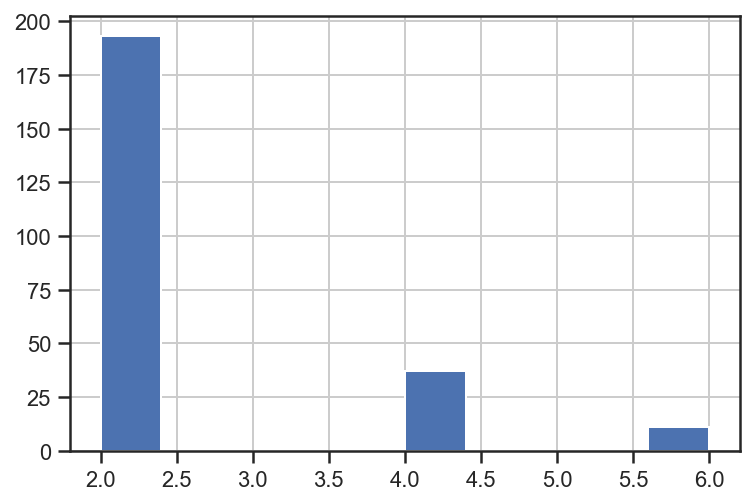

In [158]:
df_all_samples = pd.concat(all_samples)
df_all_samples.drop_duplicates(subset=["conceptUri"])

# unique occupations per category
df_all_samples.groupby("gbn_classification_short_list").count()
print(df_all_samples.drop_duplicates().groupby("gbn_classification_short_list").count
      ().iloc[:, 0])

# duplicates per category
df_all_samples["duplicate"] = df_all_samples.duplicated()
print(df_all_samples.groupby("gbn_classification_short_list").sum())

# all occupations in the sample at least twice?
df_all_samples.groupby("preferredLabel").count().iloc[:, 0].hist()

df_all_samples.groupby("preferredLabel").count()